# 📺 Netflix Data Analysis using Python


## Project Objective

The objective of this project is to analyze Netflix's content dataset using Python and perform Exploratory Data Analysis (EDA). The project aims to discover trends related to movies, TV shows, countries, genres, ratings, actors, release patterns, and movie durations through data visualization.

### Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib

In [53]:
import pandas as pd

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

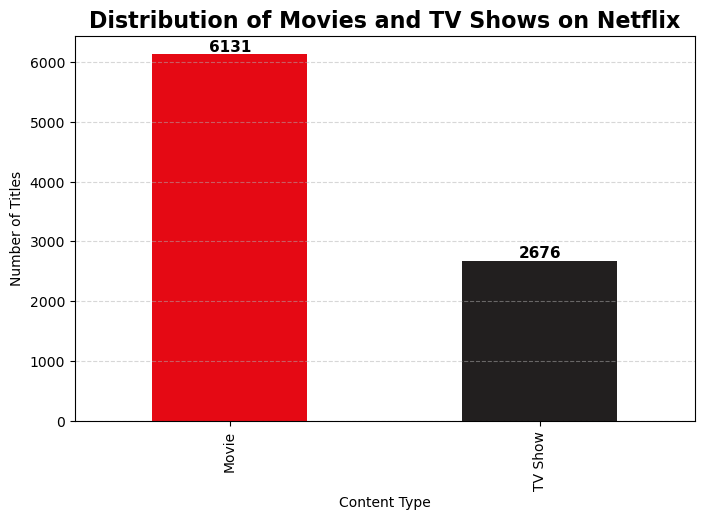

In [27]:
import matplotlib.pyplot as plt

ax = df['type'].value_counts().plot(
    kind='bar',
    color=['#E50914', '#221F1F'],
    figsize=(8,5)
)

plt.title("Distribution of Movies and TV Shows on Netflix",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container,
                 fontsize=11,
                 fontweight='bold')
plt.show()

## 1. Distribution of Movies and TV Shows on Netflix

### Observation

Netflix hosts **6,131 Movies** and **2,676 TV Shows**, meaning approximately **70%** of its catalog consists of movies. This suggests that Netflix has historically invested more heavily in movie content than episodic television, offering users a broader selection of films.

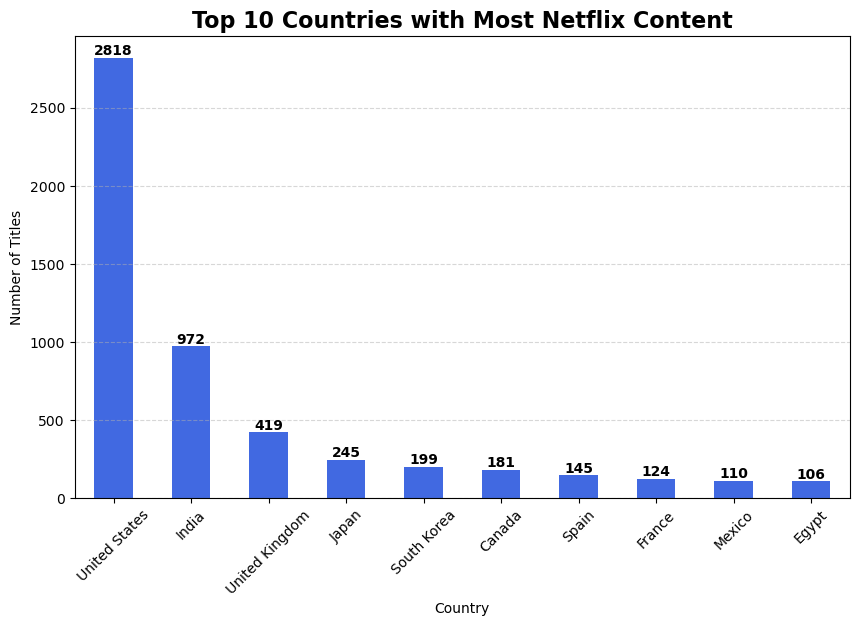

In [19]:
plt.figure(figsize=(10,6))

ax = top_countries.plot(
    kind='bar',
    color='royalblue'
)

plt.title("Top 10 Countries with Most Netflix Content",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(axis='y',
         linestyle='--',
         alpha=0.5)

for container in ax.containers:
    ax.bar_label(container,
                 fontsize=10,
                 fontweight='bold')

plt.show()

## 2. Top 10 Countries with Most Netflix Content

### Observation

The **United States** dominates Netflix's content library with **2,818 titles**, significantly higher than any other country. **India** ranks second with **972 titles**, followed by the **United Kingdom (419)** and **Japan (245)**. This indicates that Netflix has a particularly strong presence in the U.S. market while also investing heavily in content from India and other major entertainment industries.

In [21]:
df['date_added'].head(10)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: object

In [22]:
df['date_added'].isnull().sum()

np.int64(10)

In [23]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

In [24]:
df['year_added'] = df['date_added'].dt.year

In [25]:
content_per_year = df['year_added'].value_counts().sort_index()

content_per_year

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

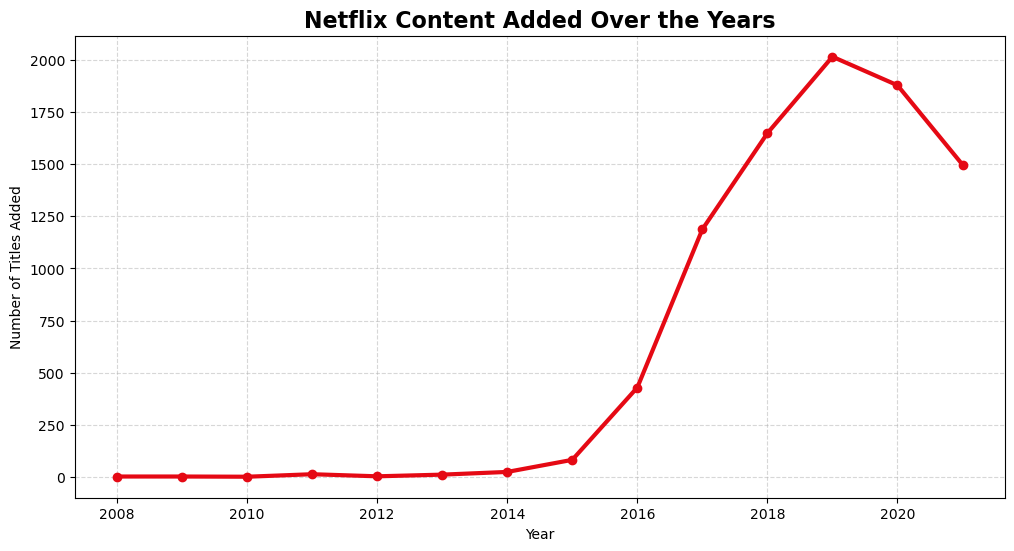

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    content_per_year.index,
    content_per_year.values,
    marker='o',
    color='#E50914',
    linewidth=3
)

plt.title(
    "Netflix Content Added Over the Years",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 3. Netflix Content Added Over the Years

### Observation

Netflix's content additions remained relatively low until 2015. From 2016 onwards, the platform experienced rapid growth, reaching its highest number of new titles in 2019. After the peak, content additions declined slightly in 2020 and 2021.

In [28]:
top_ratings = df['rating'].value_counts().head(10)

top_ratings

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

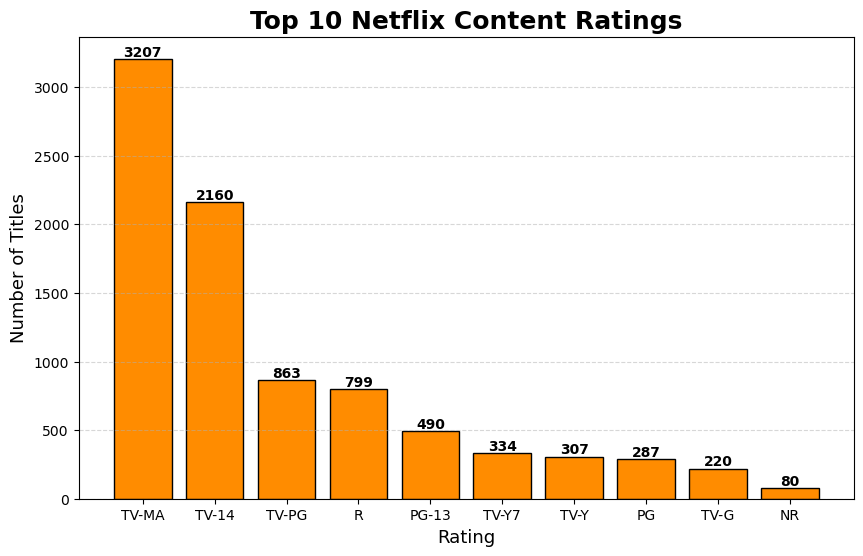

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    top_ratings.index,
    top_ratings.values,
    color='darkorange',
    edgecolor='black'
)

plt.title('Top 10 Netflix Content Ratings', fontsize=18, fontweight='bold')
plt.xlabel('Rating', fontsize=13)
plt.ylabel('Number of Titles', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        int(height),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

## 4. Top 10 Netflix Content Ratings

### Observation

TV-MA is the most common content rating on Netflix, indicating that the platform offers a large amount of mature content intended for adult audiences. TV-14 and TV-PG also represent a significant portion of the catalog, showing that Netflix maintains a balanced collection suitable for teenagers and families as well.

In [30]:
genres = df['listed_in'].str.split(', ').explode()

In [31]:
top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

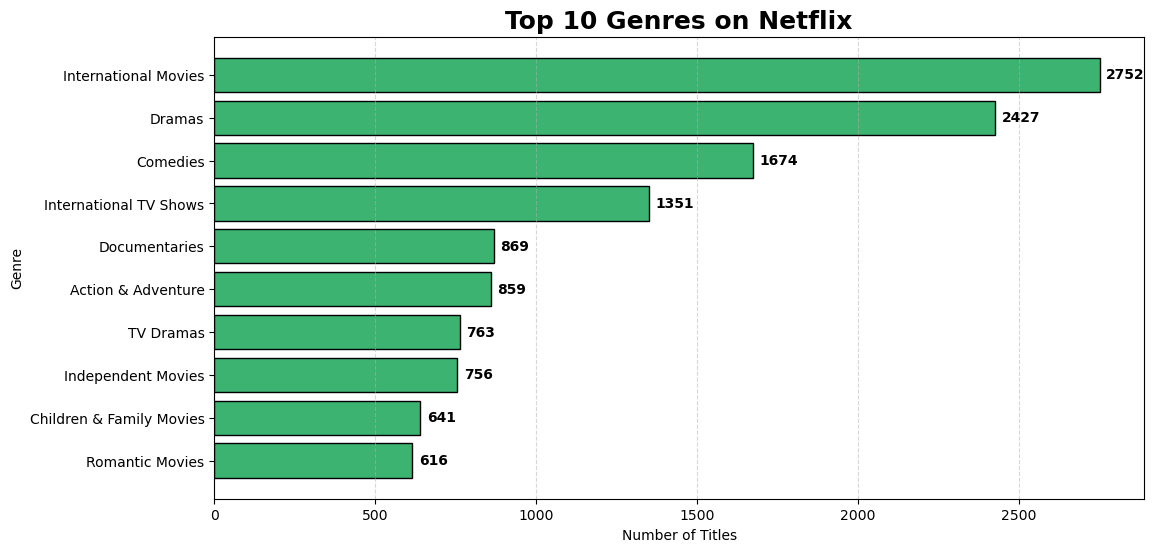

In [32]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_genres.index,
    top_genres.values,
    color='mediumseagreen',
    edgecolor='black'
)

plt.title(
    "Top 10 Genres on Netflix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        int(width),
        va='center',
        fontweight='bold'
    )

plt.gca().invert_yaxis()

plt.show()

## 5. Top 10 Genres on Netflix

### Observation

International Movies and Dramas are among the most common genres available on Netflix, highlighting the platform's strong focus on global entertainment. The popularity of Comedies, Documentaries, and Action & Adventure also indicates that Netflix maintains a diverse content library catering to a wide range of audience preferences.

In [33]:
directors = df['director'].dropna()

In [34]:
top_directors = directors.str.split(', ').explode().value_counts().head(10)

top_directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64

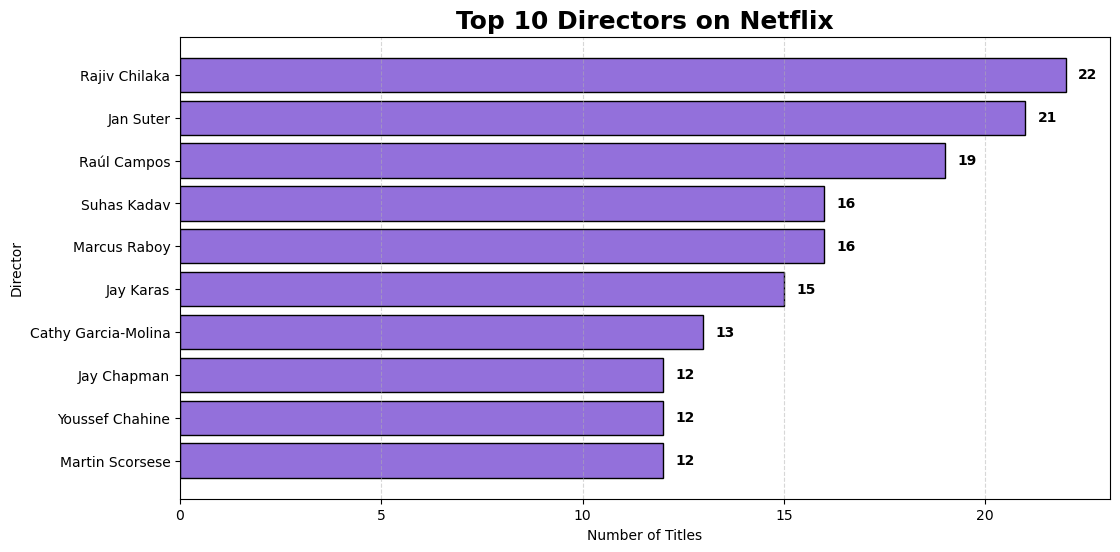

In [35]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_directors.index,
    top_directors.values,
    color='mediumpurple',
    edgecolor='black'
)

plt.title(
    "Top 10 Directors on Netflix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        int(width),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.gca().invert_yaxis()

plt.show()

## 6. Top 10 Directors on Netflix

### Observation

Rajiv Chilaka appears as the most featured director on Netflix among the top ten directors. The relatively close title counts among the leading directors suggest that Netflix collaborates with a diverse range of filmmakers rather than relying heavily on only a few individuals, contributing to a varied and balanced content library.

In [36]:
actors = df['cast'].dropna()

In [37]:
top_actors = actors.str.split(', ').explode().value_counts().head(10)

top_actors

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

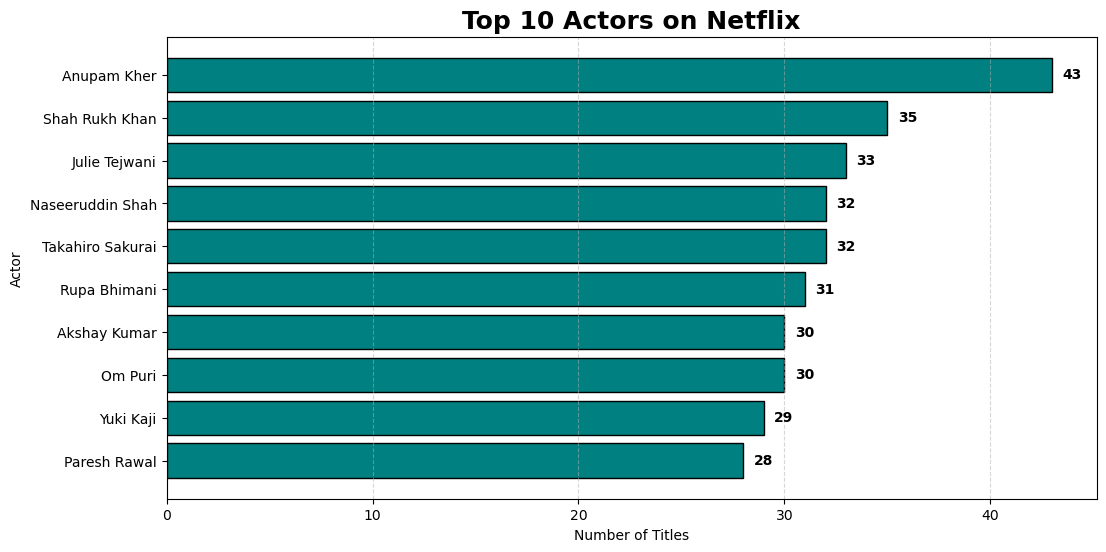

In [38]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_actors.index,
    top_actors.values,
    color='teal',
    edgecolor='black'
)

plt.title(
    "Top 10 Actors on Netflix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(width),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.gca().invert_yaxis()

plt.show()

## 7. Top 10 Actors on Netflix

### Observation

Anupam Kher appears as the most featured actor on Netflix among the top ten actors. The presence of actors from different countries indicates that Netflix collaborates with a diverse talent pool, offering content across multiple languages, regions, and genres.

In [44]:
movies = df[df['type'] == 'Movie'].copy()

In [45]:
movies['duration'].head()

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
Name: duration, dtype: object

In [46]:
movies['duration_minutes'] = movies['duration'].str.extract('(\d+)')[0]

In [47]:
movies[['duration','duration_minutes']].head()

,duration,duration_minutes
0,90 min,90
6,91 min,91
7,125 min,125
9,104 min,104
12,127 min,127


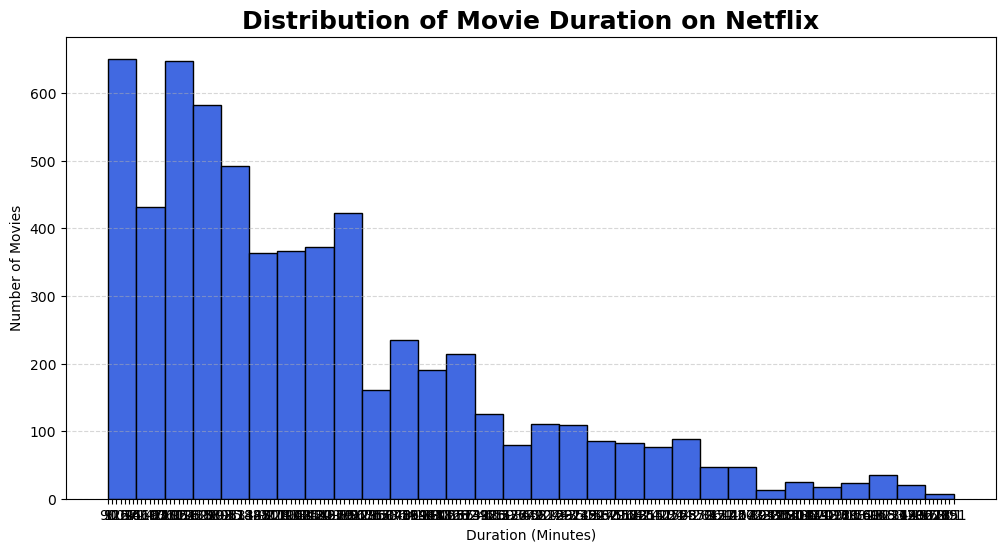

In [49]:
plt.figure(figsize=(12,6))

plt.hist(
    movies['duration_minutes'].dropna(),
    bins=30,
    color='royalblue',
    edgecolor='black'
)

plt.title("Distribution of Movie Duration on Netflix", fontsize=18, fontweight='bold')
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 8. Distribution of Movie Duration

### Observation

Most Netflix movies have a duration between **80 and 120 minutes**, indicating that feature-length films dominate the platform. Very short and very long movies are comparatively less common, showing that Netflix primarily focuses on standard movie durations preferred by a broad audience.

In [50]:
rating_counts = df['rating'].value_counts().head(10)

rating_counts

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

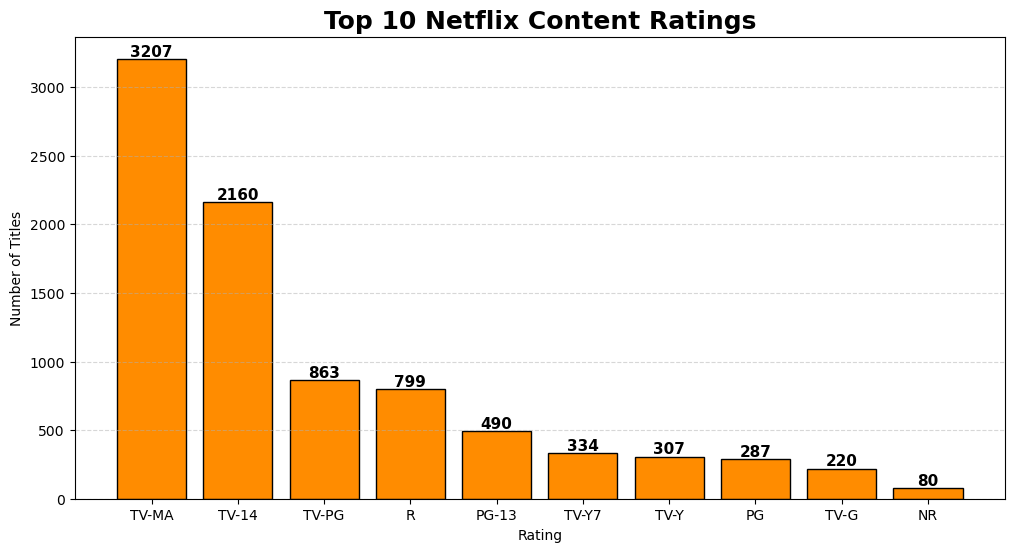

In [51]:
plt.figure(figsize=(12,6))

plt.bar(
    rating_counts.index,
    rating_counts.values,
    color='darkorange',
    edgecolor='black'
)

# Numbers on bars
for i, value in enumerate(rating_counts.values):
    plt.text(i, value + 20, str(value),
             ha='center',
             fontsize=11,
             fontweight='bold')

plt.title("Top 10 Netflix Content Ratings",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 9. Top 10 Netflix Content Ratings

### Observation

TV-MA is the most common content rating on Netflix, indicating that the platform primarily offers mature content for adult audiences. TV-14 and TV-PG are also widely represented, showing that Netflix maintains a balanced collection suitable for teenagers and families as well.

# Final Conclusion

This analysis of Netflix's dataset provides valuable insights into the platform's content library.

Key findings include:

- Netflix hosts significantly more Movies than TV Shows.
- The United States contributes the highest number of titles, followed by India and the United Kingdom.
- Content additions increased rapidly after 2016, reaching their peak around 2019 before declining slightly.
- International Movies and Dramas are the most common genres available on Netflix.
- TV-MA is the most frequent content rating, indicating a strong focus on mature audiences.
- Most movies have a duration between 80 and 120 minutes.
- Netflix features actors from diverse countries, highlighting its global content strategy.

Overall, Netflix offers a diverse and internationally focused content library with a strong emphasis on movies, mature audiences, and global entertainment.